# V3 moneyness performance — 5-year monthly study

**This notebook is the computational source of truth.** The matching PDF is written from the same payload.

This report classifies the **same** option contracts as `V3_5y_monthly_empirical_study` into DOTM / OTM / ATM / ITM / DITM. It does not change filters, calibration, contracts, LSM settings, or the market benchmark.

| Item | Setting |
|------|---------|
| Models | GBM, GARCH, Heston, Merton, GARCH–Merton, Heston–Merton |
| Companies | SPY, AAPL, MSFT (pooled in both analyses) |
| Regimes | Crisis, Normal, Late-cycle, COVID (pooled in Analysis 1; separate in Analysis 2) |
| Contracts | Monday nearest-ATM listed calls from the main study (`n = 560` per model) |
| Moneyness | `m = S/K` (calls) |
| Primary metric | RMSE% |
| Secondary | MAE, Bias $, **Bias%**, Early-exercise fraction |


## 0. Methodology

### Same design as the main study
5-year lookback, monthly recalibration, V3 filters (no-arbitrage, DTE 7–60, |S/K−1|≤10%, liquidity), Euler-corrected Heston, option-implied Heston NLS, LSM with 2,000 paths and seed 42. No look-ahead.

### Moneyness rule (calls)
Let `m = S/K`.

| Bucket | Rule |
|--------|------|
| DOTM | m < 0.98 |
| OTM | 0.98 ≤ m < 0.995 |
| ATM | 0.995 ≤ m ≤ 1.005 |
| ITM | 1.005 < m ≤ 1.02 |
| DITM | m > 1.02 |

These five bins partition the main-study 10% moneyness filter. The Monday ATM sampler concentrates mass in ATM.

### Metrics
- RMSE% = 100 × √ mean(((model − market)/market)²)
- Bias $ = mean(model − market)
- Bias% = 100 × mean((model − market)/market)
- BEST = lowest RMSE% among models with n > 0


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_5y_monthly_moneyness_study as mx
panel = mx.load_panel()
payload = mx.build_payload(panel)
pdf = mx.write_pdf(payload)
print('n_overall', payload['n_overall'])
print('PDF', pdf)

## 1. Shared sample counts


In [1]:
display(HTML('counts'))

Regime,DOTM,OTM,ATM,ITM,DITM,Total
2008-2009,9,29,32,33,6,109
2013-2014,0,5,142,3,0,150
2018-2019,0,4,140,7,0,151
2019-2020,0,6,139,5,0,150
All,9,44,453,48,6,560


## 2. Analysis 1 — Overall moneyness


### Table M1. DOTM  ·  m < 0.98  ·  n = 9  ·  **BEST = GARCH**


In [1]:
tab = payload['analysis1']['DOTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,9,34.05,1.4244,-1.1924,-21.63,21.1%,
GARCH,9,21.64,0.8050,-0.0372,+2.38,19.0%,BEST
Heston,9,29.23,0.9680,+0.9132,+24.32,24.5%,
Merton,9,34.64,1.3509,-1.0390,-20.13,21.0%,
GARCH–Merton,9,25.29,0.6120,+0.4969,+14.40,22.8%,
Heston–Merton,9,30.15,1.0959,+1.0959,+26.25,24.1%,


### Table M2. OTM  ·  0.98 ≤ m < 0.995  ·  n = 44  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['OTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,44,49.46,1.2906,+0.1551,+11.45,23.7%,
GARCH,44,48.00,1.1531,+0.6753,+26.97,22.4%,
Heston,44,38.22,1.1941,+0.7458,+24.04,24.9%,BEST
Merton,44,47.77,1.2642,+0.0880,+9.69,21.1%,
GARCH–Merton,44,58.00,1.4045,+1.0952,+39.92,21.2%,
Heston–Merton,44,40.60,1.2858,+0.7081,+24.79,21.5%,


### Table M3. ATM  ·  0.995 ≤ m ≤ 1.005  ·  n = 453  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['ATM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,453,51.79,1.7660,+0.8007,+29.31,27.2%,
GARCH,453,47.80,1.7973,+1.2940,+31.56,26.8%,
Heston,453,47.34,2.0440,+1.7212,+35.22,28.6%,BEST
Merton,453,50.53,1.7374,+0.7108,+27.59,23.9%,
GARCH–Merton,453,57.91,2.2129,+1.8342,+43.00,24.5%,
Heston–Merton,453,48.23,1.9697,+1.6094,+32.34,23.2%,


### Table M4. ITM  ·  1.005 < m ≤ 1.02  ·  n = 48  ·  **BEST = Merton**


In [1]:
tab = payload['analysis1']['ITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,48,27.69,0.9486,-0.0166,-3.77,30.4%,
GARCH,48,34.67,0.9633,+0.6668,+20.80,28.4%,
Heston,48,30.93,1.2401,+0.9054,+18.06,31.6%,
Merton,48,27.31,0.9035,-0.1262,-6.26,27.3%,BEST
GARCH–Merton,48,40.71,1.1511,+0.9857,+28.26,27.1%,
Heston–Merton,48,31.46,1.2118,+0.8959,+18.76,26.7%,


### Table M5. DITM  ·  m > 1.02  ·  n = 6  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['DITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,6,21.41,0.8883,-0.7720,-8.50,31.0%,
GARCH,6,36.86,0.6065,+0.5236,+24.19,24.2%,
Heston,6,17.20,0.3569,+0.2325,+9.70,31.5%,BEST
Merton,6,20.01,0.8392,-0.7487,-9.35,25.5%,
GARCH–Merton,6,44.94,0.8441,+0.8441,+32.48,21.2%,
Heston–Merton,6,20.11,0.4556,+0.3904,+12.86,33.1%,


### Figure M1 — Model × Moneyness RMSE% heatmap


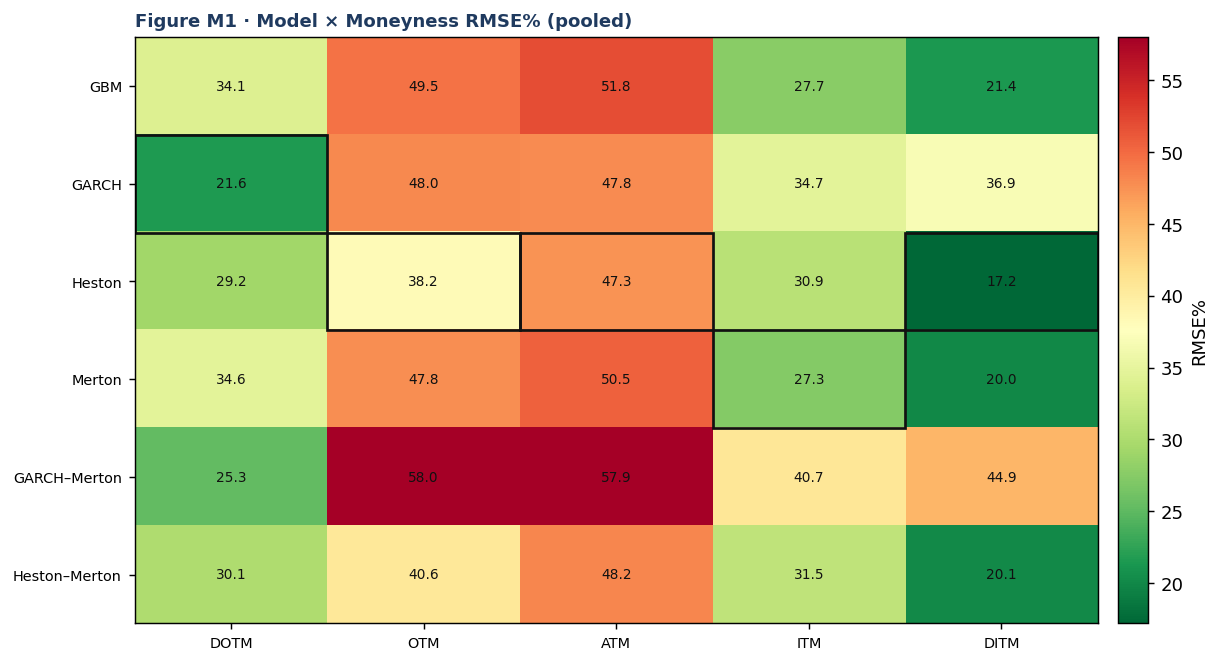

In [1]:
pass

## 3. Analysis 2 — Regime × moneyness


### Figure M2 — RMSE% heatmaps by regime


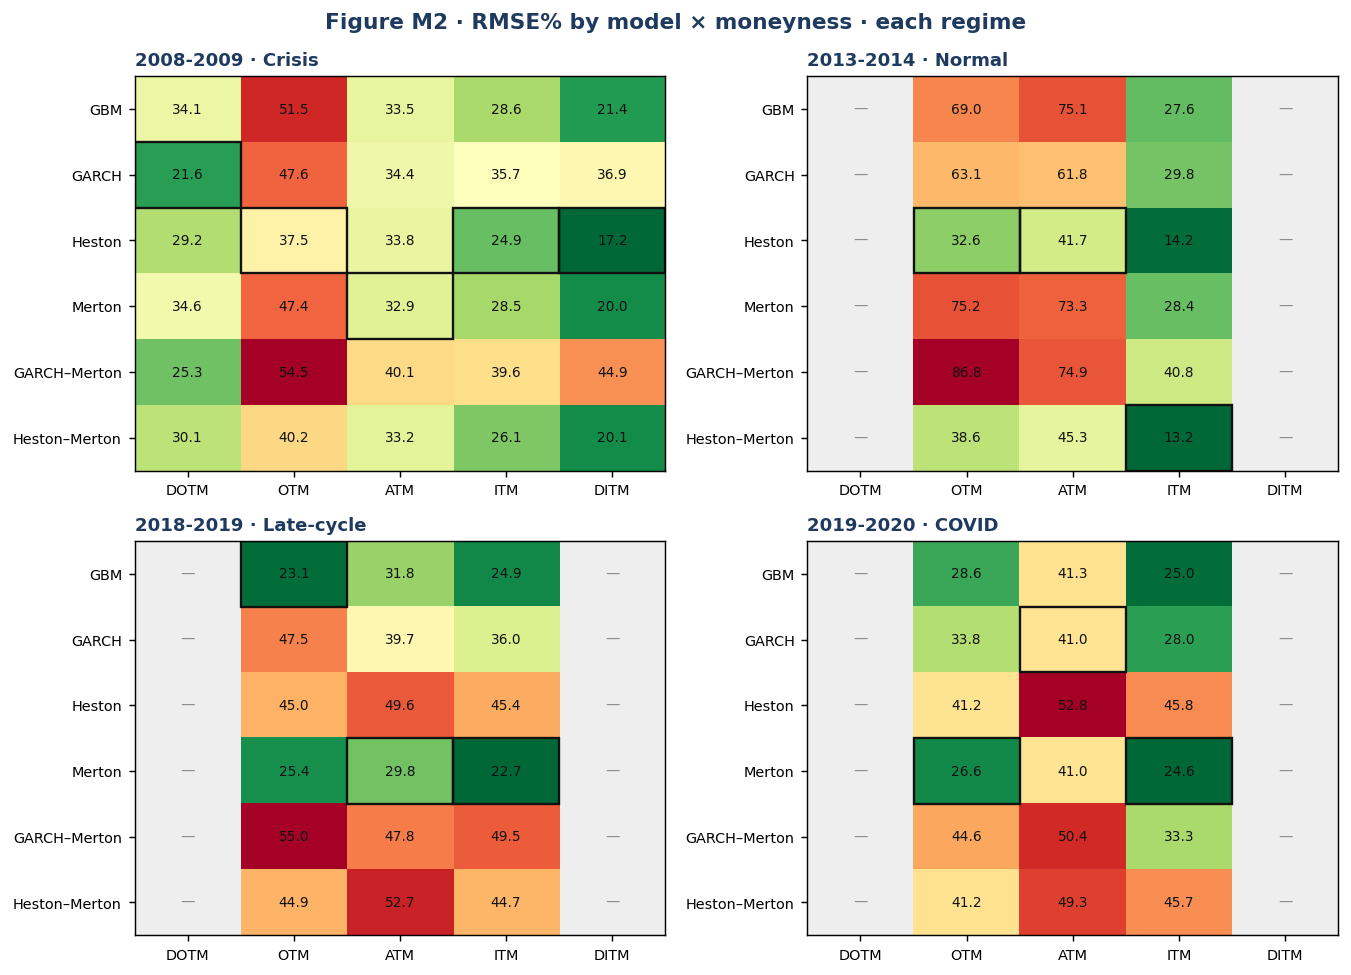

In [1]:
pass

### Table M6 — Best model by regime × moneyness


In [1]:
display(HTML('m6'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,GARCH,Heston,Merton,Heston,Heston
2013-2014,—,Heston,Heston,Heston–Merton,—
2018-2019,—,GBM,Merton,Merton,—
2019-2020,—,Merton,GARCH,Merton,—


### Table M7 — n by regime × moneyness


In [1]:
display(HTML('m7'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,9,29,32,33,6
2013-2014,0,5,142,3,0
2018-2019,0,4,140,7,0
2019-2020,0,6,139,5,0


## 4. Findings

- DOTM (n = 9): BEST = GARCH with RMSE% = 21.64, Bias% = +2.38.

- OTM (n = 44): BEST = Heston with RMSE% = 38.22, Bias% = +24.04.

- ATM (n = 453): BEST = Heston with RMSE% = 47.34, Bias% = +35.22.

- ITM (n = 48): BEST = Merton with RMSE% = 27.31, Bias% = -6.26.

- DITM (n = 6): BEST = Heston with RMSE% = 17.20, Bias% = +9.70.

- Overall, the ranking does change with moneyness: DOTM → GARCH, OTM → Heston, ATM → Heston, ITM → Merton, DITM → Heston.

- Inside regimes, the BEST model also changes with moneyness in: 2008-2009, 2013-2014, 2018-2019, 2019-2020.

- These comparisons use the Monday nearest-ATM sample, so ATM is the only well-populated bucket after 2009. DOTM/DITM results rest on few 2008–2009 quotes and should be read as descriptive, not as a high-powered test.


## 5. Re-run

```python
import run_v3_5y_monthly_moneyness_study as mx
payload = mx.run()
```

Requires the main study contract CSVs under `V3-Models_result/results/empirical_study_5y_monthly/contracts/`.
